In [1]:
# 自动重载本地模块，便于边改边跑
%load_ext autoreload
%autoreload 2
%aimport -graph_registry  # Exclude from autoreload!

from IPython.core.interactiveshell import InteractiveShell
# 让 Jupyter 单元格显示所有表达式结果
InteractiveShell.ast_node_interactivity = 'all'
from ipykernel import get_connection_file

In [2]:
import sys
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ['MODELSCOPE_CACHE']="/data0/modelscope/AI-ModelScope"
import json
from functools import partial
import itertools
from itertools import product, chain
from typing import Tuple, List, Optional
from collections import Counter
from dataclasses import dataclass
import math

import circuitsvis as cv
from circuitsvis.tokens import colored_tokens, colored_tokens_multi

# from pptree import Node as TNode, print_tree
sys.path.append('/home/hushengchun/project/BTOM-transformerlens/pptree')
import pptree
from pptree import Node as TNode, print_tree
from common_utils import join_lists, topk_md, numpy, show_topk, mr

from llm import *
from min_arc import *
from model_hooks import *
from attribute import *
from vis import *
from seeds.common import *
# from seeds.test import *

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F 
import einops
from einops import rearrange
import transformers
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, GPTQConfig, BitsAndBytesConfig
_ = torch.set_grad_enabled(False)

In [4]:
# 统一缓存已加载模型，避免重复加载
models = {}

In [5]:
# bitsandbytes 4bit 量化配置（NF4 + fp16 计算）
bnbconfig = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4'
)

In [6]:
# 加载 HF 基座模型（后续可用于与 TL 模型结果对齐）
device = 'cuda:0'
model_name = "/data0/modelscope/qwen3/models/Qwen/Qwen3-8B"
model_base = AutoModelForCausalLM.from_pretrained(model_name,
    # device_map="cpu",
    attn_implementation="eager",
    output_hidden_states=True,
    device_map='auto',
    quantization_config=bnbconfig,
    low_cpu_mem_usage=True,
    torch_dtype=torch.float16,
    local_files_only=True,
    trust_remote_code=True,
    # cache_dir="/data0/hushengchun/transformers",
    # proxies = {'http': '192.168.53.250:10801', 'https': '192.168.53.250:10801'},
)
# tokenizer 绑定到模型对象，便于后续统一调用
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_base.tokenizer = tokenizer

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [7]:
models[model_name] = model_base

space_token = 'Ġ';  newline_token = 'Ċ'  # for BPE tokenizers
L, H, V = model_base.config.num_hidden_layers, model_base.config.num_attention_heads, model_base.config.vocab_size

In [7]:
import transformer_lens
print(transformer_lens.__file__)
from transformer_lens import HookedTransformer
import transformer_lens.utils as utils
from transformer_lens.utils import repeat_along_head_dimension, get_attention_mask
import gc

/home/xd/miniconda3/envs/test/lib/python3.11/site-packages/transformer_lens/__init__.py


In [8]:
# 将同一 HF 权重加载成 TransformerLens 结构，方便做可解释性分析
from pathlib import Path
model_name = "/".join(Path(model_name).parts[-2:])
model = HookedTransformer.from_pretrained(model_name,
    hf_model=model_base,
    use_split_qkv_attention=False,
    load_in_4bit=True,
    tokenizer=tokenizer,
    device='cuda',
    device_map='auto',
    # n_devices=2,
    move_to_device=True,
    torch_dtype=torch.float16,
    center_writing_weights=False,
    center_unembed=False,
    fold_ln=False,
    fold_value_biases=False,
    trust_remote_code=True,
)
# 记录到模型缓存字典
models[model_name] = model

# 使用 TL 配置重新刷新模型维度信息
space_token = 'Ġ';  newline_token = 'Ċ'  # for BPE tokenizers
L, H, V = model.cfg.n_layers, model.cfg.n_heads, model.cfg.d_vocab

Loaded pretrained model Qwen/Qwen3-8B into HookedTransformer


In [10]:
# 释放不再使用的 HF 基座模型显存
del model_base
gc.collect()
torch.cuda.empty_cache()

NameError: name 'model_base' is not defined

In [ ]:
# （可选分支）加载另一套 GPTQ 模型用于对比实验
device = 'cuda:0'
cache_dir = '/data0/modelscope/'
# model_name = 'Qwen/Qwen2.5-72B-Instruct'
# model_name = 'Qwen/Qwen2.5-72B-Instruct-AWQ'
model_name = 'Qwen/Qwen2.5-72B-Instruct-GPTQ-Int4'
# model_name = 'Qwen/Qwen2.5-72B-Instruct'
if model_name not in models:
    model_dir = cache_dir + model_name
    model_dir = model_name
    gptq_config = GPTQConfig(bits=4, group_size=128, desc_act=False, use_exllama=True, exllama_config={"version": 2})
    model = AutoModelForCausalLM.from_pretrained(model_dir,
        # load_in_4bit=True, bnb_4bit_quant_type='nf4', #use_safetensors=False)
        torch_dtype=torch.float16, quantization_config=GPTQConfig, trust_remote_code=True,
        local_files_only=True, low_cpu_mem_usage=True, device_map=device)
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model.tokenizer = tokenizer
    models[model_name] = model
    
# 刷新 tokenizer 与模型维度信息
tokenizer = AutoTokenizer.from_pretrained(model_dir)
space_token = 'Ġ';  newline_token = 'Ċ'  # for BPE tokenizers
L, H, V = model.config.num_hidden_layers, model.config.num_attention_heads, model.config.vocab_size

In [11]:
import ast
# 要评估的模型标识（写入 Result.model 字段）
api_models = [
    'qwen3-32b',
]

# 读取 Hi-ToM 数据，并把 index 字段还原成 Python 结构
hi_tom_path = '/home/hushengchun/project/BTOM-transformerlens/data_uniform/Hi_ToM_order_1.csv'
df_tom = pd.read_csv(hi_tom_path)
df_tom['index'] = df_tom['index'].apply(ast.literal_eval)

# 控制样本规模（至少 20 条）
n_samples = max(20, len(df_tom))
df_tom = df_tom.head(n_samples)

# 将每条数据整理成统一的 Result 对象
results = []
for i, row in df_tom.iterrows():
    prompt = row['prompt']
    answer = row['answer']
    choices_str = row['choices']
    index_map = [row['index']]
    choices = [c.split('. ')[1].strip() for c in choices_str.split(', ')]
    candidate_ids = [tokenizer.encode(' ' + choice)[0] for choice in choices]
    label = tokenizer.encode(' ' + answer)[0]
    
    prompt_tokens = tokenizer.encode(prompt)
    answer_idx = len(prompt_tokens)
    for api_model in api_models:
        results.append(Result(
            index=i,
            model=api_model,
            prompt=prompt,
            answers=[answer],
            answer_indices=[answer_idx],
            candidate_ids=candidate_ids,
            labels=[label],
            n_tokens=answer_idx,
            index_map=index_map,
        ))

answer_heads = [(51, 6),(53, 51), (55, 22), (59, 21)]
character_heads = [(47, 61), (51, 40)]
k_heads= [(46, 0)]

In [12]:
# run_with_cache 仅保存后续归因所需的关键 hook
names_filter = [
    f"blocks.{layer}.ln1.hook_scale" for layer in range(model.cfg.n_layers)
] + [
    f"blocks.{layer}.hook_mlp_out" for layer in range(model.cfg.n_layers)
] + [
    f"blocks.{layer}.hook_resid_pre" for layer in range(model.cfg.n_layers)
] + [
    f"blocks.{layer}.ln2.hook_scale" for layer in range(model.cfg.n_layers)
] + [
    f"ln_final.hook_scale"
] + [
    f"blocks.{layer}.attn.hook_z" for layer in range(model.cfg.n_layers)
] + [
    f"ln_final.hook_normalized"
]

In [13]:
# 当前实验默认使用全部样本
_results = results

In [14]:
# 用 TransformerLens 路径前向并缓存中间量，写回每条样本结果
for r in tqdm(results):
    # model_inputs = tokenizer([r.prompt], return_tensors="pt").to(model.cfg.device if model.cfg.device is not None else model.device)
    model_inputs = model.to_tokens(r.prompt, prepend_bos=False, padding_side='left')
    output_logits, cache = model.run_with_cache(model_inputs, names_filter=names_filter)
    r.outputs = get_outputs_from_cache(model, cache)
    # 记录预测文本、正确性与目标 token 对数概率
    r.responses, r.is_corrects, r.logprobs = [], [], []
    for answer, ans_idx, label in zip(r.answers, r.answer_indices, r.labels):
        logits = output_logits[0, ans_idx-1]
        response = tokenizer.decode(logits.argmax(dim=-1).item())
        r.responses.append(response)
        r.is_corrects.append(response.strip().strip('"').strip("'") == answer)
        r.logprobs.append(logits.log_softmax(dim=-1)[label].item())

100%|██████████| 100/100 [01:16<00:00,  1.30it/s]


In [ ]:
# 用 HF 原生路径前向，作为与 TL 路径对照
torch.cuda.empty_cache()
for r in tqdm(results):
    model_inputs = tokenizer([r.prompt], return_tensors="pt").to(model_base.device)
    set_hooks(model_base)
    output = model_base(**model_inputs, output_hidden_states=True)
    r.outputs = get_outputs(model_base, output)
    # 记录预测文本、正确性与目标 token 对数概率
    r.responses, r.is_corrects, r.logprobs = [], [], []
    for answer, ans_idx, label in zip(r.answers, r.answer_indices, r.labels):
        logits = output.logits[0, ans_idx-1]
        response = tokenizer.decode(logits.argmax(dim=-1).item())
        r.responses.append(response)
        r.is_corrects.append(response.strip().strip('"').strip("'") == answer)
        r.logprobs.append(logits.log_softmax(dim=-1)[label].item())

In [ ]:
# encoding = tokenizer(results[0].prompt)
# ids = encoding['input_ids']
# tokens = tokenizer.convert_ids_to_tokens(ids)

# # 显示对应关系
# for i, (token_id, token) in enumerate(zip(ids, tokens)):
#     print(f"{i:4d}: {token_id:6d} -> {token}")

In [15]:
# 可在此按关系筛选样本；默认仍使用全部样本
_results = results # [r for r in results if r.rel_fn == 'right_of']; r = _results[-1]

In [16]:
# 基于 TL 模型维度初始化归因图，并补齐统一属性 
graph = Graph(dataset_size=len(_results), hidden_size=model.cfg.d_model)
model.device = model.cfg.device
model.dtype = model.cfg.dtype

In [17]:
import attribute
from contextlib import contextmanager

# 备份原逻辑：仅在需要时覆盖 dequant 上下文
_orig_use_dequant = attribute.use_dequant_projections

@contextmanager
def _patched_use_dequant_projections(module, layer, grad_inputs):
    # TL attention: 有 W_O，但没有 o_proj
    is_tl_attn = hasattr(module, "W_O") and not hasattr(module, "o_proj")
    if is_tl_attn:
        yield  # no-op，相当于不执行 with 内替换逻辑
        return
    with _orig_use_dequant(module, layer, grad_inputs):
        yield

# 将 patch 注入 attribute 模块
attribute.use_dequant_projections = _patched_use_dequant_projections

In [18]:
# 构建根节点（lm_head）并初始化归因树
lmhead = Node(L, None, 'lm_head', attn_pattern='A-->A-')
nodes = [lmhead]
for n in nodes: graph.add_node(n)
# 优先使用 model_base；若不存在则回退到 model
selected_model = model_base if 'model_base' in globals() and model_base is not None else model
root = tnode = add_tnode(_results, selected_model, nodes); print_tree(root)

 L36


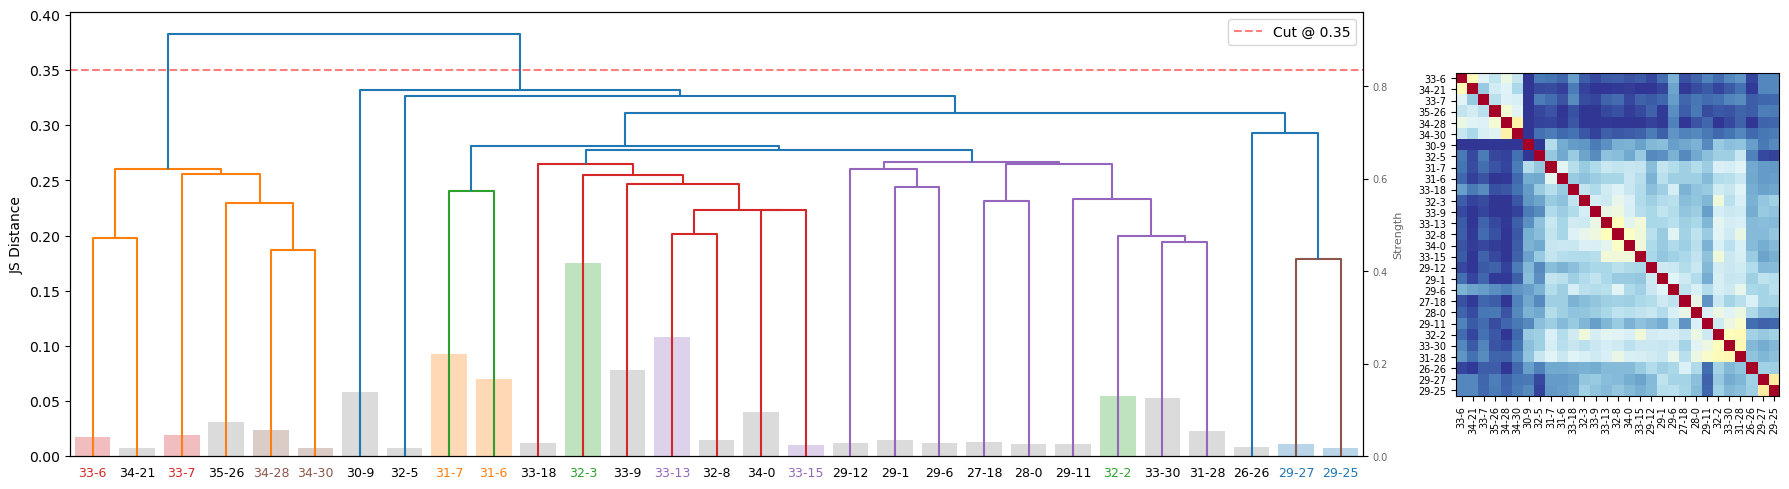

CLUSTERING SUMMARY: 2 groups, 29 heads
  Cohesion (avg intra): 0.267
  Separation (avg sep): 0.353
  Sep/Cohesion ratio:   1.32 (higher = better)
📦 GROUP 1 (6 heads) | intra=0.246, sep=0.319.    Heads: 35-26, 34-28, 33-7, 33-6, 34-21, 34-30
📦 GROUP 2 (23 heads) | intra=0.288, sep=0.319.    Heads: 32-3, 33-13, 31-7, 33-9, 31-6, 30-9, 32-2, 33-30, 34-0, 31-28, 29-1, 32-8, 27-18, 29-12, 33-18, 29-6, 29-11, 29-27, 28-0, 33-15, 26-26, 29-25, 32-5


In [19]:
# 对当前层归因结果做 head 聚类，并计算簇内/簇间指标
d = tnode.data
d.groups, d.metrics, _, _ = cluster_heads(d.attn_attrs_ds, threshold=0.35, strengths=d.top_heads, model_config=selected_model.cfg,
    figsize=(18, 5), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9)

In [23]:
sample = _results[6]

In [48]:
model.cfg

HookedTransformerConfig:
{'NTK_by_parts_factor': 8.0,
 'NTK_by_parts_high_freq_factor': 4.0,
 'NTK_by_parts_low_freq_factor': 1.0,
 'NTK_original_ctx_len': 8192,
 'act_fn': 'silu',
 'attention_dir': 'causal',
 'attn_only': False,
 'attn_scale': 11.313708498984761,
 'attn_scores_soft_cap': -1.0,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 128,
 'd_mlp': 12288,
 'd_model': 4096,
 'd_vocab': 151936,
 'd_vocab_out': 151936,
 'decoder_start_token_id': None,
 'default_prepend_bos': False,
 'device': 'cuda',
 'dtype': torch.float16,
 'eps': 1e-06,
 'experts_per_token': None,
 'final_rms': True,
 'from_checkpoint': False,
 'gated_mlp': True,
 'init_mode': 'gpt2',
 'init_weights': False,
 'initializer_range': 0.02,
 'load_in_4bit': True,
 'model_name': 'Qwen3-8B',
 'n_ctx': 2048,
 'n_devices': 1,
 'n_heads': 32,
 'n_key_value_heads': 8,
 'n_layers': 36,
 'n_params': 7851737088,
 'normalization_type': 'RMS',
 'num_experts'

In [24]:
def tokenize_plus(model: HookedTransformer, inputs: List[str]):
    """
    Tokenizes the input strings using the provided model.

    Args:
        model (HookedTransformer): The model used for tokenization.
        inputs (List[str]): The list of input strings to be tokenized.

    Returns:
        tuple: A tuple containing the following elements:
            - tokens (torch.Tensor): The tokenized inputs.
            - attention_mask (torch.Tensor): The attention mask for the tokenized inputs.
            - input_lengths (torch.Tensor): The lengths of the tokenized inputs.
            - n_pos (int): The maximum sequence length of the tokenized inputs.
    """
    # if model.cfg.model_name == "gpt2":
    #     prepend_bos = True
    # else:
    #     prepend_bos = False
    tokens = model.to_tokens(inputs, prepend_bos=False, padding_side='left')
    attention_mask = get_attention_mask(model.tokenizer, tokens, True)
    input_lengths = attention_mask.sum(1)
    n_pos = attention_mask.size(1)
    return tokens, attention_mask, input_lengths, n_pos

token_ids, attention_mask, input_lengths, n_pos = tokenize_plus(model, sample.prompt)
tokens = tokenizer.convert_ids_to_tokens(token_ids[0])
tokens

['You',
 'Ġare',
 'Ġa',
 'Ġhelpful',
 'Ġassistant',
 '.',
 'ĠWhen',
 'Ġthe',
 'Ġuser',
 'Ġasks',
 'Ġyou',
 'Ġa',
 'Ġquestion',
 ',',
 'Ġyou',
 'Ġcan',
 'Ġnot',
 'Ġshow',
 'Ġany',
 'Ġreasoning',
 'Ġor',
 'Ġthinking',
 'Ġprocess',
 'Ġbut',
 'Ġdirectly',
 'Ġprovide',
 'Ġthe',
 'Ġanswer',
 'Ġwithin',
 'Ġ<',
 'answer',
 '>',
 'Ġ</',
 'answer',
 '>',
 'Ġtags',
 '.',
 'ĠYou',
 'Ġneed',
 'Ġto',
 'Ġprovide',
 'Ġan',
 'Ġanswer',
 'Ġwithin',
 'Ġ',
 '1',
 '0',
 'Ġtokens',
 'Ġand',
 'Ġyou',
 'Ġdo',
 'Ġnot',
 'Ġneed',
 'Ġto',
 'Ġshow',
 'Ġyour',
 'Ġreasoning',
 'Ġprocess',
 'Ġabout',
 'Ġthe',
 'Ġpsychological',
 'Ġchanges',
 'Ġof',
 'Ġcharacters',
 '.Ċ',
 'Note',
 ':',
 'ĠYou',
 'Ġshould',
 'Ġassume',
 'Ġthe',
 'Ġfollowing',
 '.Ċ',
 '(',
 '1',
 ')',
 'ĠAn',
 'Ġagent',
 'Ġwitnesses',
 'Ġeverything',
 'Ġand',
 'Ġevery',
 'Ġmovement',
 'Ġbefore',
 'Ġexiting',
 'Ġa',
 'Ġroom',
 '.Ċ',
 '(',
 '2',
 ')',
 'ĠAn',
 'Ġagent',
 'ĠA',
 'Ġcan',
 'Ġinfer',
 'Ġanother',
 'Ġagent',
 'ĠB',
 "'s",
 'Ġmental',
 'Ġstat

In [ ]:
character_id = []
item_id = []
corrupt_id = []
exited_id = []
for id, token in enumerate(tokens):
    if token == 'Ġ'+sample.answers[0]:
        container_id = id
container_id

[]

[]

158

[161, 174]

In [44]:
# 指定 head 可视化其注意力
colored_tokens_multi(*show_attn(sample, selected_model, 19, 21, downstreams=tnode.data.nodes, start=_results[0].index_map[0]['start'], pos_ids = container_id))#, start=100))

in✗ start=136, stop=205


In [25]:
# 汇总每个 top head 的分数、准确率与多种 pattern 匹配得分
attn_patterns = ['A-->V', 'A-->A-', 'V->VK_C', 'V->VK_I', 'A-->QK_C', 'A-->QK_I']
df = pd.DataFrame([(l, h, round(score, 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=False).item(), 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=True).item(), 4), 
    round(ap_scores[attn_patterns[0]].mean().item(), 4),
    round(ap_scores[attn_patterns[1]].mean().item(), 4),
    round(ap_scores[attn_patterns[2]].mean().item(), 4),
    round(ap_scores[attn_patterns[3]].mean().item(), 4),
    round(ap_scores[attn_patterns[4]].mean().item(), 4),
    round(ap_scores[attn_patterns[5]].mean().item(), 4))
    for (l, h), score in d.top_heads.items() if (ap_scores := mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h))],
    columns=['layer', 'head', 'score', 'acc', 'acc0'] + attn_patterns)
# 以 TSV 形式打印，便于后续复制或筛选
print(df.to_csv(sep='\t', index=True))
# _ = plt.figure(figsize=(8, 2)); _ = sns.heatmap(np.array(attr[60:, :, 0].cpu()), cbar=True)

	layer	head	score	acc	acc0	A-->V	A-->A-	V->VK_C	V->VK_I	A-->QK_C	A-->QK_I
0	33	9	0.2223	0.19	0.19	0.0884	0.0014	0.0089	0.0009	0.0812	0.007
1	33	13	0.2159	0.09	0.09	0.124	0.0044	0.0022	0.0011	0.0394	0.0252
2	33	16	0.1785	0.09	0.07	0.065	0.0016	0.0015	0.0009	0.0221	0.0093
3	33	30	0.1592	0.29	0.29	0.1699	0.0124	0.0005	0.0008	0.0184	0.012
4	34	5	0.1399	0.0	0.0	0.1633	0.0034	0.0024	0.0007	0.0126	0.013
5	31	7	0.1377	0.07	0.07	0.0734	0.0033	0.0013	0.0003	0.0136	0.0012
6	32	2	0.1245	0.11	0.11	0.237	0.0023	0.0005	0.0008	0.0169	0.0153
7	31	6	0.1083	0.12	0.12	0.0767	0.0028	0.002	0.0005	0.0201	0.0033
8	31	4	0.1064	0.08	0.08	0.1396	0.0013	0.002	0.0002	0.0434	0.0023
9	35	26	0.1037	0.0	0.0	0.0021	0.5312	0.0096	0.0284	0.0005	0.0026
10	34	0	0.0994	0.14	0.14	0.1131	0.0042	0.0037	0.001	0.0775	0.0178
11	31	28	0.0936	0.0	0.0	0.3084	0.0093	0.0013	0.0007	0.0206	0.0083
12	33	12	0.079	0.0	0.0	0.0764	0.0018	0.0009	0.0009	0.0162	0.0187
13	34	28	0.077	0.08	0.0	0.003	0.4063	0.003	0.0078	0.0013	0.0019
14	34	17	0.06

In [27]:
# 按阈值从 DataFrame 中挑选候选 attn_k 节点
nodes = [Node(int(l), int(h), 'attn_k', attn_pattern='A-->V') for l, h, s, acc, acc0, aps1, aps2, aps3, aps4, aps5, aps6 in df.values[:25]
         if int(h) < H and aps1 > 0.2]
# 打印候选节点，人工确认
for n in nodes: print(n)

Node(32,2,'attn_k')
Node(31,28,'attn_k')
Node(28,0,'attn_k')


In [28]:
# 手动指定一个上游节点并连边到当前树节点
nodes = [Node(32, 2, 'attn_k', attn_pattern='A-->V')]
for n in nodes: add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
# 基于新增节点继续向上扩展归因树
tnode = add_tnode(_results, selected_model, nodes, parent=tnode); print_tree(root)

 L36┐
    └L32 A-->V x1


In [ ]:
# 检查 attn_attrs_ds 的数据
for (l, h), aa in tnode.data.attn_attrs_ds.items():
    print(f"Head ({l}, {h}):")
    print(f"  Shape: {aa.shape}")
    print(f"  Min: {aa.min().item():.6f}, Max: {aa.max().item():.6f}")
    print(f"  Sum per row (first 3): {aa.sum(dim=-1)[:3].tolist()}")
    print(f"  Has NaN: {torch.isnan(aa).any().item()}")
    print(f"  Has Inf: {torch.isinf(aa).any().item()}")
    print(f"  All zeros rows: {(aa.sum(dim=-1) == 0).sum().item()}")
    print()

In [28]:
d = tnode.data
d.groups, d.metrics, _, _ = cluster_heads(d.attn_attrs_ds, threshold=0.45, strengths=d.top_heads, model_config=selected_model.config,
    figsize=(12, 3), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9)

AttributeError: 'HookedTransformer' object has no attribute 'config'

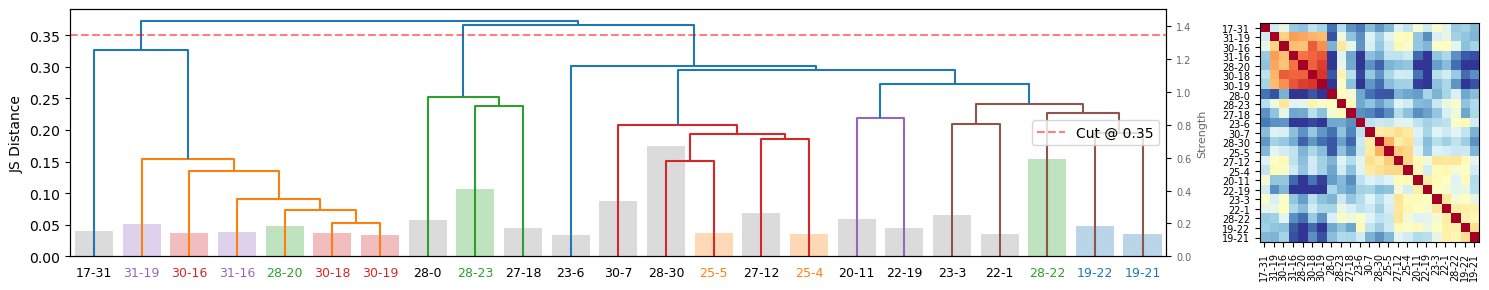

CLUSTERING SUMMARY: 3 groups, 23 heads
  Cohesion (avg intra): 0.232
  Separation (avg sep): 0.264
  Sep/Cohesion ratio:   1.14 (higher = better)
📦 GROUP 1 (7 heads) | intra=0.178, sep=0.205.    Heads: 31-19, 28-20, 17-31, 31-16, 30-16, 30-18, 30-19
📦 GROUP 2 (3 heads) | intra=0.247, sep=0.205.    Heads: 28-23, 28-0, 27-18
📦 GROUP 3 (13 heads) | intra=0.271, sep=0.234.    Heads: 28-30, 28-22, 30-7, 27-12, 23-3, 20-11, 19-22, 22-19, 25-5, 25-4, 22-1, 19-21, 23-6


In [29]:
d = tnode.data
d.groups, d.metrics, _, _ = cluster_heads(d.attn_attrs_ds, threshold=0.35, strengths=d.top_heads, model_config=selected_model.cfg,
    figsize=(15, 3), width_ratios=(5, 1), bar_height=0.5, leaf_font_size=9)

In [30]:
attn_patterns = ['A-->V', 'A-->A-', 'V->VK_C', 'V->VK_I', 'A-->QK_C', 'A-->QK_I']
df = pd.DataFrame([(l, h, round(score, 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=False).item(), 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=True).item(), 4), 
    round(ap_scores[attn_patterns[0]].mean().item(), 4),
    round(ap_scores[attn_patterns[1]].mean().item(), 4),
    round(ap_scores[attn_patterns[2]].mean().item(), 4),
    round(ap_scores[attn_patterns[3]].mean().item(), 4),
    round(ap_scores[attn_patterns[4]].mean().item(), 4),
    round(ap_scores[attn_patterns[5]].mean().item(), 4))
    for (l, h), score in d.top_heads.items() if (ap_scores := mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h))],
    columns=['layer', 'head', 'score', 'acc', 'acc0'] + attn_patterns)
print(df.to_csv(sep='\t', index=True))
# _ = plt.figure(figsize=(8, 2)); _ = sns.heatmap(np.array(attr[60:, :, 0].cpu()), cbar=True)

	layer	head	score	acc	acc0	A-->V	A-->A-	V->VK_C	V->VK_I	A-->QK_C	A-->QK_I
0	28	30	0.6724	0.0	0.0	0.0002	0.055	0.0014	0.0005	0.0002	0.0
1	28	22	0.5933	0.0	0.0	0.0025	0.0553	0.0085	0.0363	0.015	0.0401
2	28	23	0.4065	0.0	0.0	0.3796	0.0085	0.0058	0.0053	0.0115	0.0067
3	30	7	0.3335	0.0	0.0	0.0002	0.149	0.0333	0.0135	0.0007	0.0006
4	27	12	0.2664	0.0	0.0	0.0008	0.3971	0.0079	0.0129	0.0018	0.0016
5	23	3	0.2537	0.0	0.0	0.0007	0.3136	0.0513	0.0432	0.0097	0.0032
6	20	11	0.2286	0.0	0.0	0.0	0.5331	0.01	0.0247	0.0015	0.0003
7	28	0	0.2195	0.0	0.0	0.5214	0.0045	0.0015	0.0009	0.0028	0.0086
8	31	19	0.1938	0.0	0.0	0.0001	0.1918	0.0332	0.1487	0.0004	0.0008
9	19	22	0.1842	0.0	0.0	0.0003	0.0888	0.0824	0.1109	0.01	0.0027
10	28	20	0.1831	0.0	0.0	0.0005	0.0142	0.0002	0.0001	0.001	0.0002
11	27	18	0.1737	0.0	0.0	0.3571	0.0028	0.0	0.0018	0.0	0.0012
12	22	19	0.1708	0.0	0.0	0.0014	0.5163	0.0184	0.0137	0.0054	0.0024
13	17	31	0.1511	0.0	0.0	0.0	0.0273	0.0176	0.0026	0.0	0.0
14	31	16	0.149	0.0	0.0	0.0	0.0816	0.0041	0.0

In [ ]:
for cluster_id, heads in d.groups.items():
    for l, h in heads:
        if cluster_id == 1: t, attn_pattern = 'attn_q', 'A-->V'
        elif cluster_id == 2: t, attn_pattern = 'attn_v', 'A-->A-'
        else: continue
        n = Node(l, h, t, attn_pattern=attn_pattern)
        add_edges(graph, n, d.nodes, d.attr)

In [31]:
nodes = [Node(int(l), int(h), 'attn_q', attn_pattern='A-->V') for l, h, s, acc, acc0, aps1, aps2, aps3, aps4, aps5, aps6 in df.values[:25]
         if int(h) < H and aps1 > 0.3]
for n in nodes: print(n)

Node(28,23,'attn_q')
Node(28,0,'attn_q')
Node(27,18,'attn_q')


In [32]:
nodes = [Node(int(l), int(h), 'attn_k', attn_pattern='A-->V') for l, h in [(27, 18), (28, 0), (26, 26)]]
for n in nodes: add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
tnode = add_tnode(_results, selected_model, nodes, parent=tnode); print_tree(root)

 L36┐
    └L32 A-->V x1┐
                 └L28,27 A-->V x3


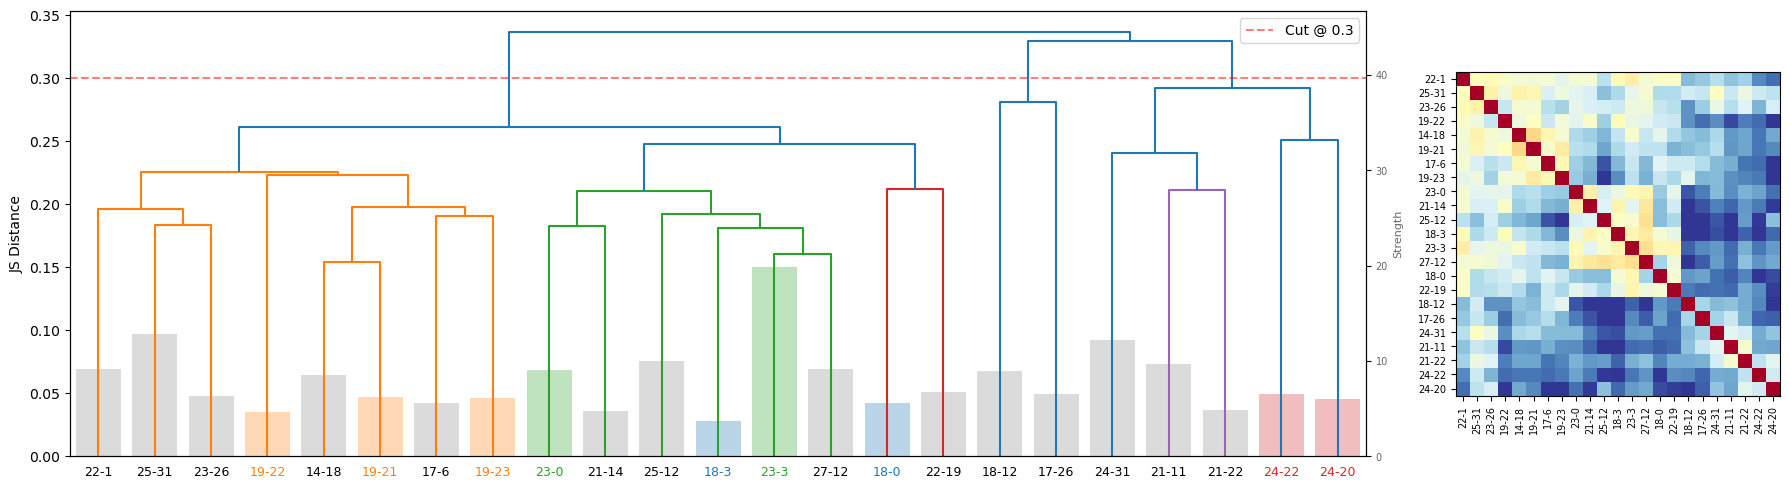

CLUSTERING SUMMARY: 3 groups, 23 heads
  Cohesion (avg intra): 0.264
  Separation (avg sep): 0.257
  Sep/Cohesion ratio:   0.97 (higher = better)
📦 GROUP 1 (16 heads) | intra=0.240, sep=0.202.    Heads: 23-3, 22-1, 27-12, 25-31, 14-18, 25-12, 23-26, 18-0, 19-21, 19-22, 23-0, 21-14, 22-19, 17-6, 19-23, 18-3
📦 GROUP 2 (2 heads) | intra=0.281, sep=0.233.    Heads: 18-12, 17-26
📦 GROUP 3 (5 heads) | intra=0.270, sep=0.202.    Heads: 24-31, 21-11, 24-22, 24-20, 21-22


In [33]:
d = tnode.data
d.groups, d.metrics, _, _ = cluster_heads(d.attn_attrs_ds, threshold=0.3, strengths=d.top_heads, model_config=selected_model.cfg,  # thld 0.5->0.4
    figsize=(18, 5), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9)

In [ ]:
d = tnode.data
d.groups, d.metrics, _, _ = cluster_heads(d.attn_attrs_ds, threshold=0.4, strengths=d.top_heads, model_config=selected_model.config,  # thld 0.5->0.4
    figsize=(18, 5), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9)

In [34]:
attn_patterns = ['A-->V', 'A-->A-', 'V->VK_C', 'V->VK_I', 'A-->QK_C', 'A-->QK_I']
df = pd.DataFrame([(l, h, round(score, 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=False).item(), 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=True).item(), 4), 
    round(ap_scores[attn_patterns[0]].mean().item(), 4),
    round(ap_scores[attn_patterns[1]].mean().item(), 4),
    round(ap_scores[attn_patterns[2]].mean().item(), 4),
    round(ap_scores[attn_patterns[3]].mean().item(), 4),
    round(ap_scores[attn_patterns[4]].mean().item(), 4),
    round(ap_scores[attn_patterns[5]].mean().item(), 4))
    for (l, h), score in d.top_heads.items() if (ap_scores := mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h))],
    columns=['layer', 'head', 'score', 'acc', 'acc0'] + attn_patterns)
print(df.to_csv(sep='\t', index=True))
# _ = plt.figure(figsize=(8, 2)); _ = sns.heatmap(np.array(attr[60:, :, 0].cpu()), cbar=True)

	layer	head	score	acc	acc0	A-->V	A-->A-	V->VK_C	V->VK_I	A-->QK_C	A-->QK_I
0	23	3	19.8262	0.0	0.0	0.0007	0.3136	0.0513	0.0432	0.0097	0.0032
1	24	31	12.2148	0.0	0.0	0.2489	0.0014	0.0052	0.0173	0.0079	0.0223
2	22	1	9.1914	0.0	0.0	0.0086	0.0297	0.0256	0.0349	0.0224	0.0284
3	27	12	9.124	0.0	0.0	0.0008	0.3971	0.0079	0.0129	0.0018	0.0016
4	25	31	12.8262	0.0	0.0	0.0054	0.0215	0.0189	0.0558	0.0142	0.0282
5	18	12	8.938	0.0	0.0	0.0054	0.0322	0.0001	0.0145	0.0043	0.0049
6	21	11	9.6426	0.0	0.0	0.1764	0.0229	0.0032	0.0063	0.0039	0.0017
7	14	18	8.563	0.0	0.0	0.0007	0.0073	0.1362	0.1031	0.0178	0.0094
8	25	12	10.0039	0.0	0.0	0.0006	0.3385	0.0251	0.0402	0.0008	0.0012
9	24	22	6.5496	0.0	0.0	0.0005	0.1843	0.0005	0.0048	0.0119	0.0089
10	24	20	5.9938	0.0	0.0	0.0001	0.0191	0.0035	0.0056	0.0267	0.0056
11	23	26	6.3333	0.0	0.0	0.0092	0.059	0.037	0.0394	0.0738	0.0258
12	18	0	5.5688	0.0	0.0	0.0005	0.0639	0.024	0.1025	0.0021	0.0031
13	19	21	6.2095	0.0	0.0	0.0019	0.0186	0.0922	0.1041	0.0262	0.0364
14	19	22	4.6437	0

In [ ]:
nodes = [Node(int(l), int(h), 'attn_q', attn_pattern='A-->V') for l, h, s, acc, acc0, aps1, aps2, aps3, aps4, aps5, aps6 in df.values[:25]
         if int(h) < H and aps1 > 0.5]
for n in nodes: print(n)

In [ ]:
for cluster_id, heads in d.groups.items():
    for l, h in heads:
        if cluster_id == 3: t, attn_pattern = 'attn_q', 'A-->V'
        else: continue
        n = Node(l, h, t, attn_pattern=attn_pattern)
        add_edges(graph, n, d.nodes, d.attr)

In [40]:
nodes = [Node(14, 18, 'attn_k', attn_pattern='V->VK_C'), Node(19, 22, 'attn_k', attn_pattern='V->VK_I')]
for n in nodes: add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
tnode = add_tnode(_results, selected_model, nodes, parent=tnode); print_tree(root)

 L36┐
    └L32 A-->V x1┐
                 └L28,27,26 A-->V x3┐
                                    └L19,14 V->VK_C x2


In [41]:
d = tnode.data
d.groups, d.metrics, _, _ = cluster_heads(d.attn_attrs_ds, threshold=0.5, strengths=d.top_heads, model_config=selected_model.config,
    figsize=(12, 3), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9)

AttributeError: 'HookedTransformer' object has no attribute 'config'

In [42]:
d = tnode.data
d.groups, d.metrics, _, _ = cluster_heads(d.attn_attrs_ds, threshold=0.5, strengths=d.top_heads, model_config=selected_model.cfg,
    figsize=(12, 3), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9)

ValueError: Distance matrix 'X' must be symmetric.

In [ ]:
attn_patterns = ['A-->V', 'A-->A-', 'V->VK_C', 'V->VK_I', 'A-->QK_C', 'A-->QK_I']
df = pd.DataFrame([(l, h, round(score, 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=False).item(), 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=True).item(), 4), 
    round(ap_scores[attn_patterns[0]].mean().item(), 4),
    round(ap_scores[attn_patterns[1]].mean().item(), 4),
    round(ap_scores[attn_patterns[2]].mean().item(), 4),
    round(ap_scores[attn_patterns[3]].mean().item(), 4),
    round(ap_scores[attn_patterns[4]].mean().item(), 4),
    round(ap_scores[attn_patterns[5]].mean().item(), 4))
    for (l, h), score in d.top_heads.items() if (ap_scores := mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h))],
    columns=['layer', 'head', 'score', 'acc', 'acc0'] + attn_patterns)
print(df.to_csv(sep='\t', index=True))
# _ = plt.figure(figsize=(8, 2)); _ = sns.heatmap(np.array(attr[60:, :, 0].cpu()), cbar=True)

In [ ]:
colored_tokens_multi(*show_attn(random.choice(_results), selected_model, 51, 10, downstreams=tnode.data.nodes, start=_results[0].index_map[0]['start']))#, start=100))

In [ ]:
for cluster_id, heads in d.groups.items():
    for l, h in heads:
        if cluster_id == 1: t, attn_pattern = 'attn_v', 'A-->A-'
        elif cluster_id == 2: t, attn_pattern = 'attn_q', 'A-->QK_C'
        elif cluster_id == 3: t, attn_pattern = 'attn_q', 'A-->V'
        elif cluster_id == 4: t, attn_pattern = 'attn_v', 'A-->X'
        elif cluster_id == 5: t, attn_pattern = 'attn_v', 'A-->QV'
        else: continue
        n = Node(l, h, t, attn_pattern=attn_pattern)
        add_edges(graph, n, d.nodes, d.attr)

In [ ]:
nodes = [Node(l, h, 'attn_v', attn_pattern='A-->V') for l, h in [(50, 60)]]
for n in nodes: add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
tnode = add_tnode(_results, selected_model, nodes, parent=tnode); print_tree(root)

In [ ]:
tnode.data.top_heads

In [ ]:
d = tnode.data
d.groups, d.metrics, _, _ = cluster_heads(d.attn_attrs_ds, threshold=0.5, strengths=d.top_heads, model_config=selected_model.config,
    figsize=(12, 3), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9)

In [ ]:
attn_patterns = ['A-->V', 'A-->A-', 'V->VK_C', 'V->VK_I', 'A-->QK_C', 'A-->QK_I']
df = pd.DataFrame([(l, h, round(score, 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=False).item(), 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=True).item(), 4), 
    round(ap_scores[attn_patterns[0]].mean().item(), 4),
    round(ap_scores[attn_patterns[1]].mean().item(), 4),
    round(ap_scores[attn_patterns[2]].mean().item(), 4),
    round(ap_scores[attn_patterns[3]].mean().item(), 4),
    round(ap_scores[attn_patterns[4]].mean().item(), 4),
    round(ap_scores[attn_patterns[5]].mean().item(), 4))
    for (l, h), score in d.top_heads.items() if (ap_scores := mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h))],
    columns=['layer', 'head', 'score', 'acc', 'acc0'] + attn_patterns)
print(df.to_csv(sep='\t', index=True))
# _ = plt.figure(figsize=(8, 2)); _ = sns.heatmap(np.array(attr[60:, :, 0].cpu()), cbar=True)

In [ ]:
from vis import merge_gqa_groups, visualize_graph
for upstream, downstream in g.edges:
    if downstream == lmhead: g.edges[(upstream, downstream)] /= 10.
try:
    vg = merge_gqa_groups(g, selected_model.config)
    visualize_graph(vg, selected_model.config)
finally:
    for upstream, downstream in g.edges:
        if downstream == lmhead: g.edges[(upstream, downstream)] *= 10.

In [ ]:
candidates = join_lists([r.answers for r in results], dedup=True)  # ['K', 'B', 'G', 'R', 'Y']
logits_mask = (torch.ones(model.config.vocab_size) * (-1e4)).to(model.device, dtype=torch.float16)
logits_mask[tokenizer.encode(' ' + ' '.join(candidates))] = 0
mask = torch.eye(model.config.num_attention_heads).to(model.device, dtype=torch.float16) # n*n
pos_ids = torch.LongTensor(r.answer_indices) - 1

In [ ]:
heads = [
    # (77, 64), 
    # (76, 64), 
    # (77, 54), 
    # (79, 10), 
    # (78, 61), 
    # (76, 26), 
    # (72, 11), 
    # (73, 64), 
    # (76, 35),
    (73, 1),  # right_of
]
for r in _results:
    indices = torch.LongTensor(r.answer_indices) - 1
    sum_output = sum(get_head_output(selected_model, r.outputs, layer, head, indices) if head < N
        else r.outputs.mlp_outputs[layer][:, indices].to(selected_model.device) for layer, head in heads)
    norm = model.model.norm
    norm.variance = r.outputs.ln_states[-1][:, indices].to(model.device)
    sum_output = model.model.norm(sum_output)
    norm.variance = None
    # sum_output = r.outputs.hidden_states[-1][:, indices].to(model.device)
    top_pred = model.lm_head(sum_output).log_softmax(dim=-1).max(dim=-1)
    top_pred.values.mean()
    [t.replace('Ġ', ' ') for t in tokenizer.convert_ids_to_tokens(top_pred.indices[0])]
    r.responses
    [' ' + a for a in r.answers]